# 5.0 Model training - LightGBM - Optuna search


## Imports


In [ ]:
import numpy as np
import pandas as pd
import joblib
import shap
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
from optuna.importance import get_param_importances
from recruit_restaurant_visitor_forecasting.config.config import (
    MODELS_DIR,
    VISIT_DATE_COL,
    RANDOM_SEED,
    AIR_GENRE_COL,
    PROCESSED_DATA_DIR
)
from recruit_restaurant_visitor_forecasting.config.features import CITY_COL
from recruit_restaurant_visitor_forecasting.config.preprocessing import DROP_COLUMNS
from recruit_restaurant_visitor_forecasting.config.modeling import (
    CV_SPLITS,
    TEST_SIZE,
    FIRST_ITER_TRIALS,
    SECOND_ITER_TRIALS,
    FS_VALID_SIZE,
    OBJECTIVE_FUNCTION
)
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_actual_pred,
    plot_daily_error_overall,
    plot_daily_error_by_group,
    plot_error_mean_std,
    plot_error_radar,
    plot_errors_boxplot
)
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
    get_daily_error_stats_table,
    MEAN_ERROR,
    STD_ERROR,
    MIN_ABS_ERROR,
    MAX_POS_ERROR,
    MAX_NEG_ERROR,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

In [ ]:
MODEL_NAME = "lgbm_optuna_recursive"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

# mlflow.set_experiment(f"recruit_restaurant_visitors_v04")

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
    mlflow_run_name="study_first_iter",
    objective_func=OBJECTIVE_FUNCTION,
)
print_best_params(study)

[I 2026-02-20 13:35:58,166] A new study created in memory with name: no-name-81a0dae8-ef98-4eb7-a085-645f0ef59d77
[I 2026-02-20 13:41:54,805] Trial 7 finished with value: 0.9252082175118383 and parameters: {'model__max_depth': 4, 'model__learning_rate': 0.034008540925574544, 'model__n_estimators': 982, 'model__subsample': 0.5165684807075048, 'model__colsample_bytree': 0.8650088516583194, 'model__min_child_samples': 26, 'model__reg_alpha': 0.005177462685806474, 'model__reg_lambda': 0.00014808307187269302, 'model__num_leaves': 11}. Best is trial 7 with value: 0.9252082175118383.
[I 2026-02-20 13:42:11,532] Trial 3 finished with value: 0.9308493132475839 and parameters: {'model__max_depth': 3, 'model__learning_rate': 0.04131180336902038, 'model__n_estimators': 955, 'model__subsample': 0.6504125174375956, 'model__colsample_bytree': 0.9340868034603774, 'model__min_child_samples': 31, 'model__reg_alpha': 0.0008668242610526284, 'model__reg_lambda': 9.243777597502136, 'model__num_leaves': 4}. 

Best parameters: {'model__max_depth': 5, 'model__learning_rate': 0.11706627917788462, 'model__n_estimators': 588, 'model__subsample': 0.9392347287157391, 'model__colsample_bytree': 0.9521126327384529, 'model__min_child_samples': 20, 'model__reg_alpha': 2.4186789653976835, 'model__reg_lambda': 0.1186116076675154, 'model__num_leaves': 28}
Best score: 0.91836


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
35,"{'model__max_depth': 5, 'model__learning_rate'...",0.135145,0.918364,0.975598,0.840594,0.833019,0.785419,1.157191,1
34,"{'model__max_depth': 5, 'model__learning_rate'...",0.135400,0.918437,0.982076,0.839221,0.831655,0.784452,1.154780,2
23,"{'model__max_depth': 5, 'model__learning_rate'...",0.133447,0.918825,0.976432,0.842744,0.832901,0.787857,1.154192,3
14,"{'model__max_depth': 5, 'model__learning_rate'...",0.133212,0.918924,0.965324,0.840609,0.837376,0.792142,1.159169,4
24,"{'model__max_depth': 5, 'model__learning_rate'...",0.135553,0.919243,0.978540,0.839242,0.833592,0.786727,1.158116,5


### SHAP feature selection

In [8]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [13]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
    mlflow_run_name="study_second_iter",
    objective_func=OBJECTIVE_FUNCTION,
)
print_best_params(study)

[I 2026-02-20 14:18:07,612] A new study created in memory with name: no-name-bdd07b16-bcab-4b22-a89a-f8b2f7e749d6
[I 2026-02-20 14:19:08,577] Trial 0 finished with value: 0.9297799474398836 and parameters: {'model__max_depth': 3, 'model__learning_rate': 0.09830430699949666, 'model__n_estimators': 493, 'model__subsample': 0.5188380475384002, 'model__colsample_bytree': 0.8745224174995996, 'model__min_child_samples': 18, 'model__reg_alpha': 0.007400418348925679, 'model__reg_lambda': 0.00027938661559758095, 'model__num_leaves': 4, 'feature_dropper__keep_count': 35}. Best is trial 0 with value: 0.9297799474398836.
[I 2026-02-20 14:19:48,307] Trial 1 finished with value: 0.9217488271579792 and parameters: {'model__max_depth': 4, 'model__learning_rate': 0.056943846305838874, 'model__n_estimators': 672, 'model__subsample': 0.629355146928346, 'model__colsample_bytree': 0.8739214660545419, 'model__min_child_samples': 24, 'model__reg_alpha': 2.0895785639789586, 'model__reg_lambda': 0.189543384912

Best parameters: {'model__max_depth': 4, 'model__learning_rate': 0.2545185934272447, 'model__n_estimators': 268, 'model__subsample': 0.7471783330625404, 'model__colsample_bytree': 0.8680283360487443, 'model__min_child_samples': 12, 'model__reg_alpha': 0.0004468882499021882, 'model__reg_lambda': 0.01663786391561546, 'model__num_leaves': 15, 'feature_dropper__keep_count': 23}
Best score: 0.91678


In [14]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
192,"{'model__max_depth': 4, 'model__learning_rate'...",0.132900,0.916785,0.946355,0.835113,0.837597,0.800936,1.163921,1
187,"{'model__max_depth': 4, 'model__learning_rate'...",0.133388,0.916787,0.944010,0.835593,0.838642,0.800095,1.165594,2
190,"{'model__max_depth': 4, 'model__learning_rate'...",0.133488,0.917016,0.944777,0.834999,0.838307,0.801067,1.165930,3
108,"{'model__max_depth': 4, 'model__learning_rate'...",0.133088,0.917184,0.945736,0.836856,0.838633,0.799820,1.164874,4
174,"{'model__max_depth': 4, 'model__learning_rate'...",0.132898,0.917257,0.948297,0.837429,0.839014,0.798039,1.163507,5


### Scores

In [15]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8501
MAE:  6.9685


In [6]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 90/90 [01:18<00:00,  1.15it/s]


In [17]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.8197
MAE:  7.2071


## Graphs

### Optuna importances

In [18]:
get_param_importances(study)

{'model__learning_rate': np.float64(0.5887405651348993),
 'model__subsample': np.float64(0.22609042128260584),
 'feature_dropper__keep_count': np.float64(0.1360084813515742),
 'model__max_depth': np.float64(0.016118392186055826),
 'model__n_estimators': np.float64(0.014793216196442752),
 'model__colsample_bytree': np.float64(0.008343404862627015),
 'model__reg_lambda': np.float64(0.007335288430553305),
 'model__min_child_samples': np.float64(0.0014786913257558807),
 'model__reg_alpha': np.float64(0.0010915392294856179)}

### SHAP explanation

In [19]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

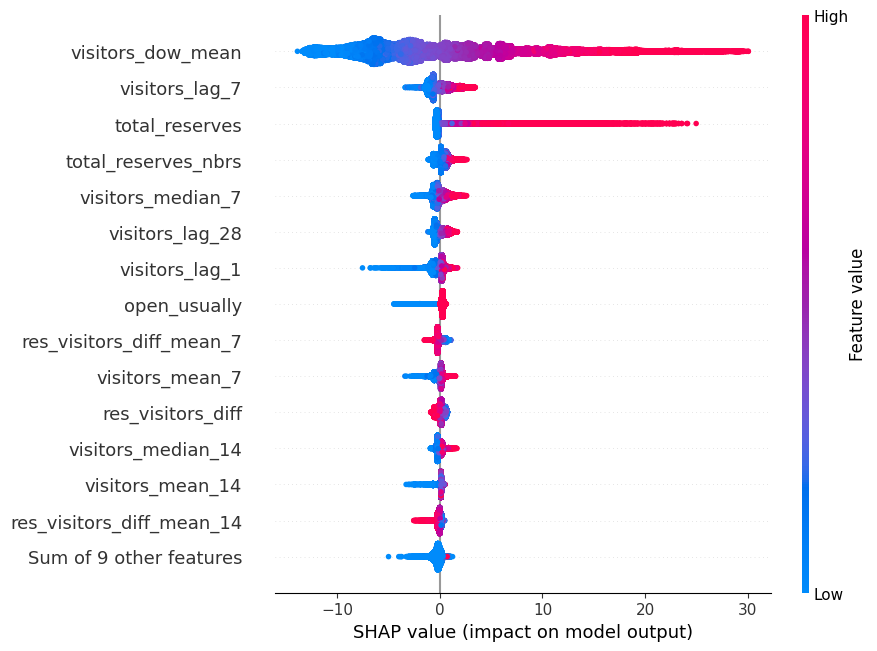

In [20]:
shap.plots.beeswarm(shap_values, max_display=15)

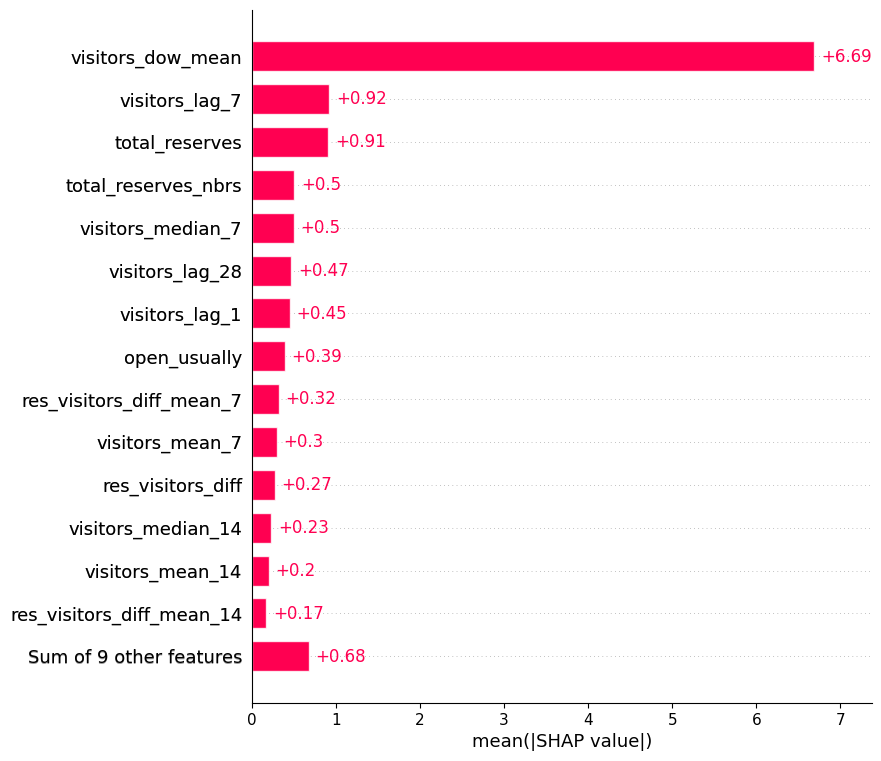

In [21]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

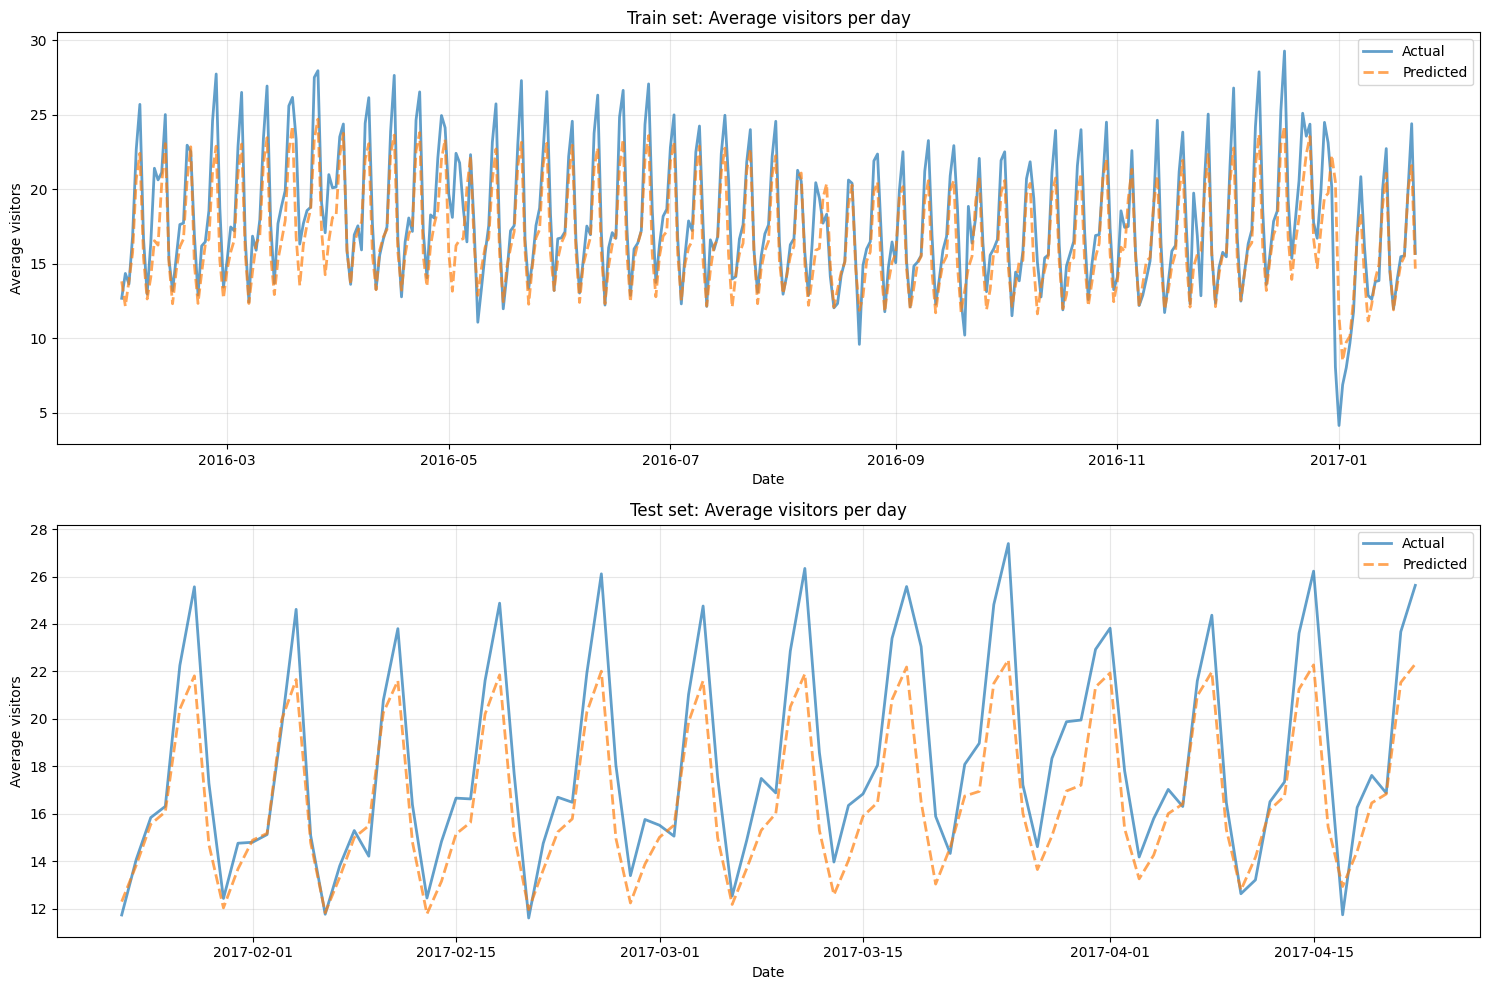

In [22]:
train_daily = merge_daily_pred(train_dates, y_train, pd.Series(y_train_pred))
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_actual_pred(axes[0], train_daily, "Train set")
plot_actual_pred(axes[1], test_daily, "Test set")

plt.tight_layout()
plt.show()

### Residuals

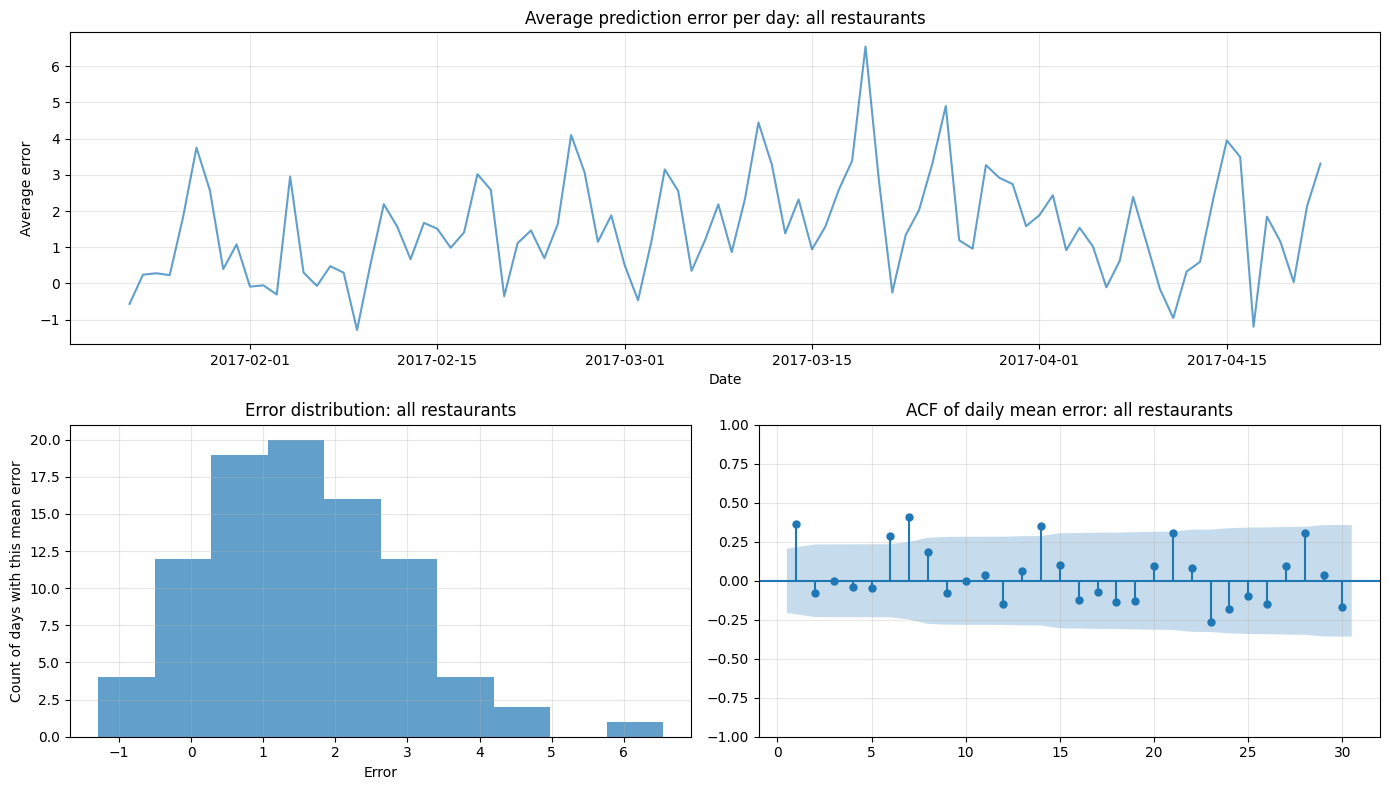

In [23]:
plot_daily_error_overall(X_test, y_test_pred, y_test)

The residuals have some seasonality, so it is likely that some dependence is not taken into account.

#### Cities

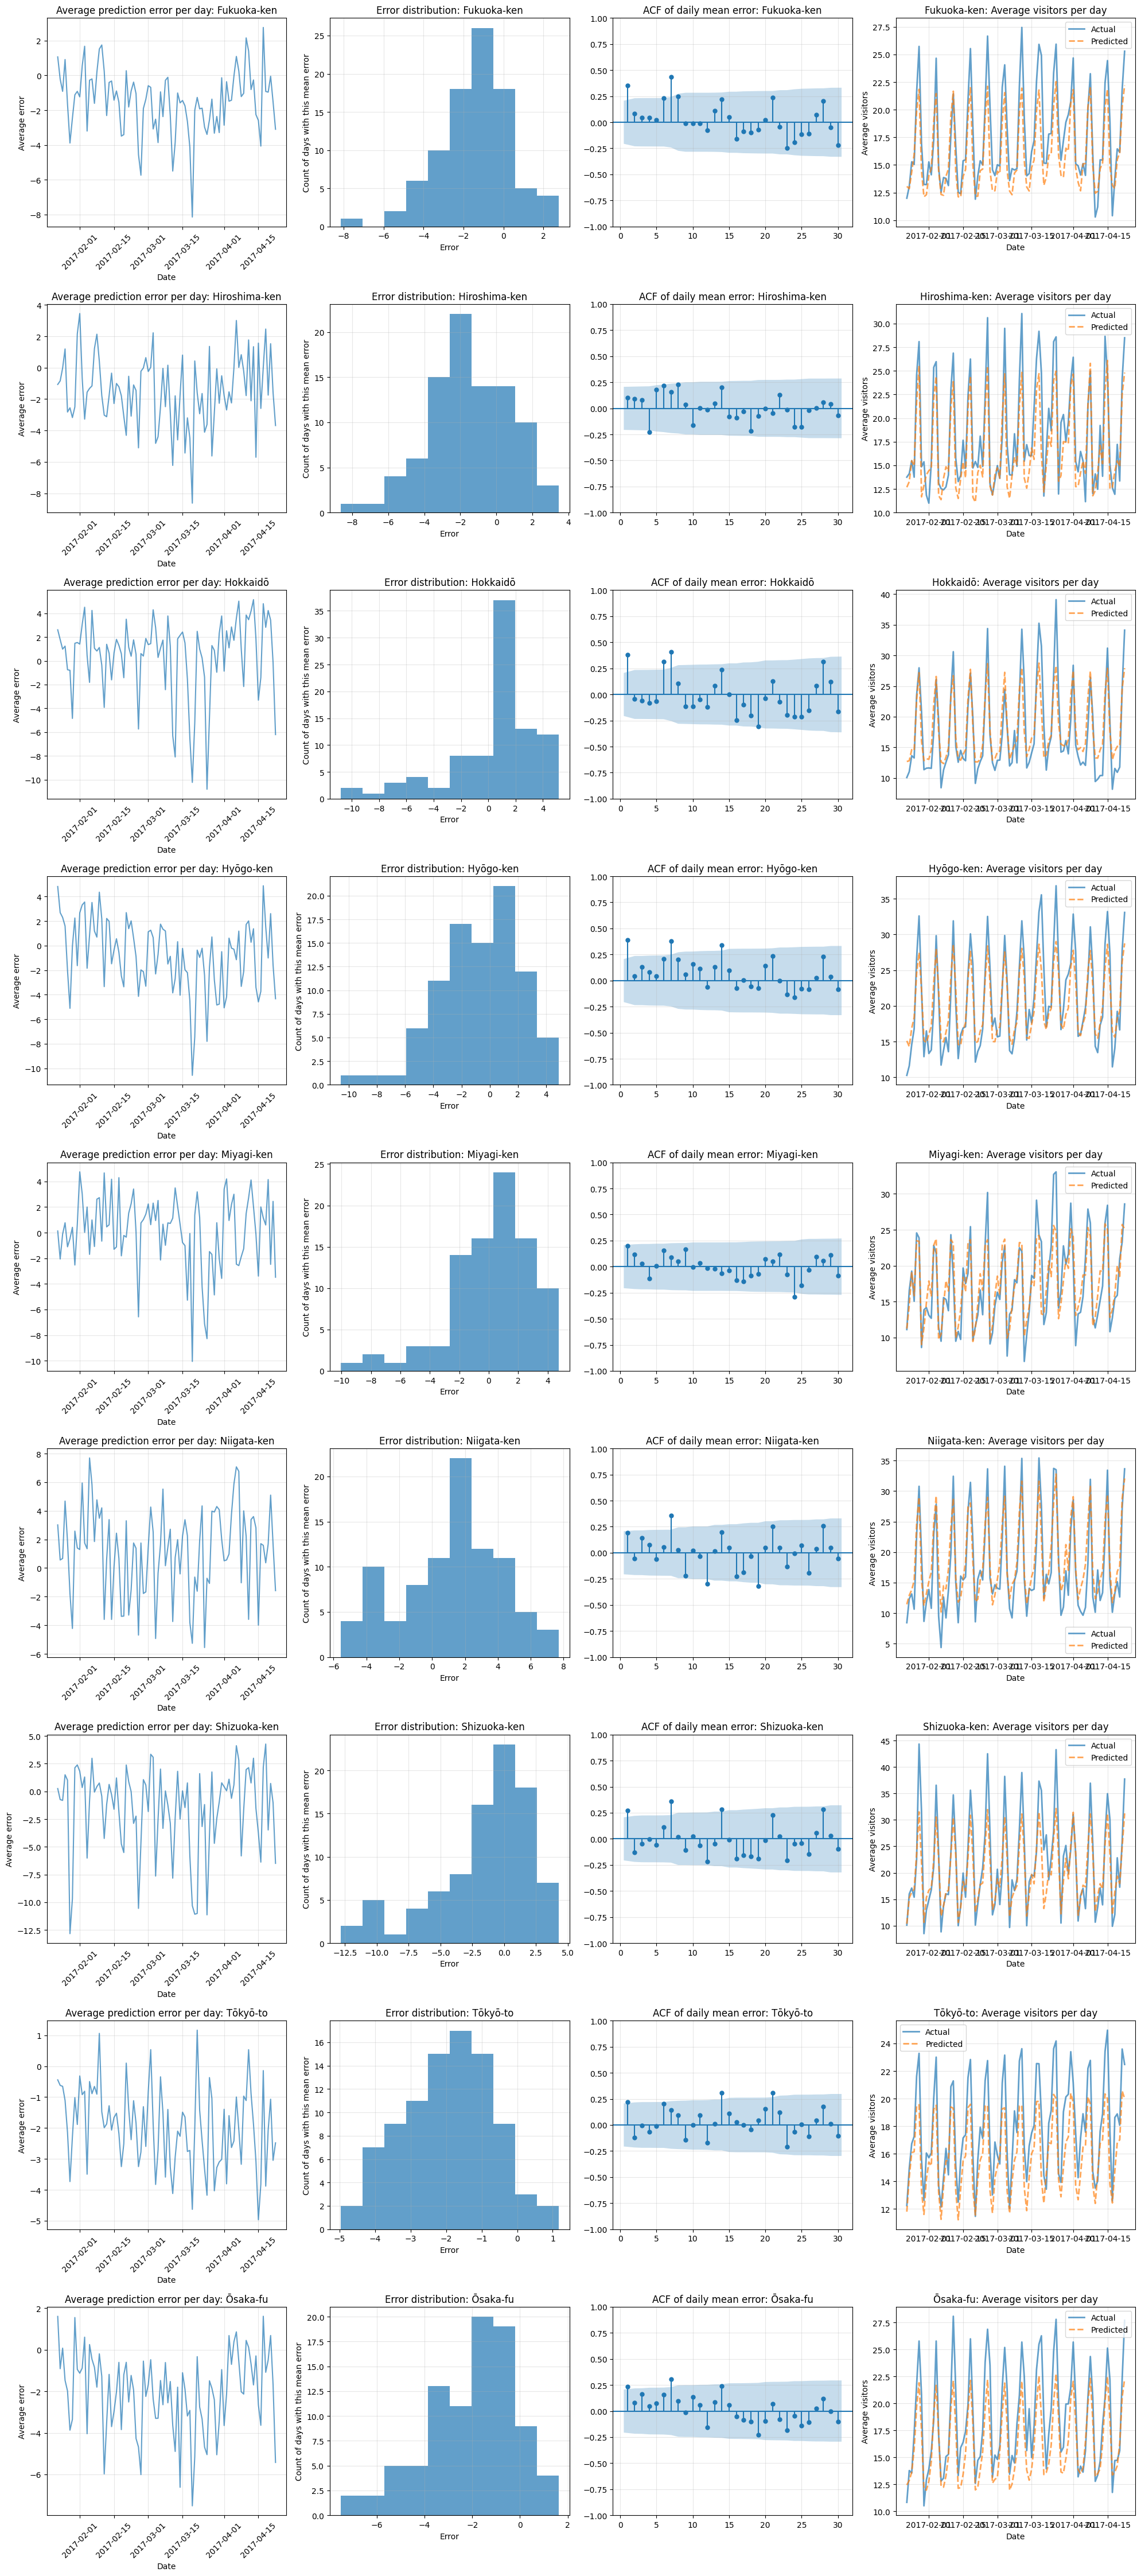

In [25]:
plot_daily_error_by_group(X_test, y_test, y_test_pred, CITY_COL)

The residuals averaged across cities don't differ significantly from each other on average. For most of them, the mean error increases between 2017-03 and 2017-04, but in some cities it's larger, and in others, smaller.

In [50]:
city_group_error_info = get_daily_error_stats_table(X_test, y_test, y_test_pred, CITY_COL)
city_group_error_info

,city,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Fukuoka-ken,-0.877,1.566,0.008,4.566,5.114,0.296,0.184,0.150,0.172,0.140,0.121,0.346,0.137,0.005,0.093,0.118,-0.008,0.012,0.140
1,Hiroshima-ken,-1.403,2.051,0.033,3.725,6.093,0.126,0.190,0.274,-0.044,0.272,0.223,0.129,0.206,0.138,-0.033,0.079,-0.007,0.026,0.143
2,Hokkaidō,0.687,2.630,0.029,5.528,8.488,0.305,0.017,0.089,0.083,-0.029,0.245,0.255,-0.047,-0.095,0.007,0.095,-0.086,0.097,0.143
3,Hyōgo-ken,-0.130,2.387,0.002,5.577,6.115,0.243,-0.007,0.292,0.265,-0.011,0.009,0.328,0.055,-0.030,0.256,0.267,-0.104,-0.010,0.337
4,Miyagi-ken,0.858,2.402,0.074,5.289,6.263,0.093,0.087,0.015,-0.191,-0.143,0.024,-0.048,-0.053,0.211,0.062,0.053,-0.037,-0.067,-0.089
5,Niigata-ken,1.056,3.043,0.008,8.143,5.312,0.266,0.170,0.290,0.149,0.007,-0.011,0.261,0.005,-0.089,0.062,-0.028,-0.214,0.029,0.065
6,Shizuoka-ken,-0.911,3.263,0.019,3.965,12.284,0.155,-0.116,0.027,0.071,-0.007,0.021,0.340,-0.112,-0.132,0.146,-0.012,-0.200,-0.108,0.358
7,Tōkyō-to,-1.187,1.152,0.016,1.430,3.949,0.257,-0.001,0.033,-0.050,0.048,0.065,-0.082,-0.085,-0.215,0.018,0.125,-0.202,-0.077,0.168
8,Ōsaka-fu,-1.143,1.828,0.002,2.456,6.060,0.254,0.230,0.346,0.181,0.191,0.114,0.252,0.076,0.036,0.256,0.191,-0.139,0.063,0.146


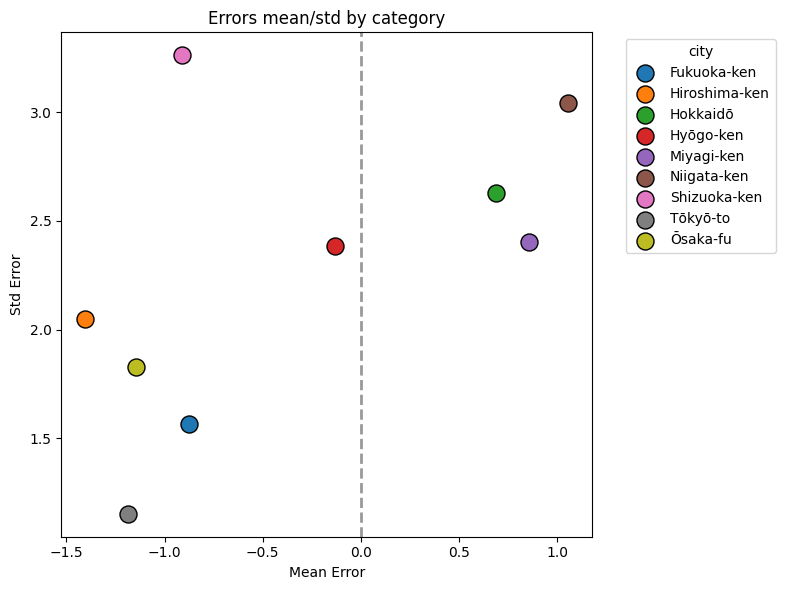

In [49]:
plot_error_mean_std(city_group_error_info, CITY_COL)

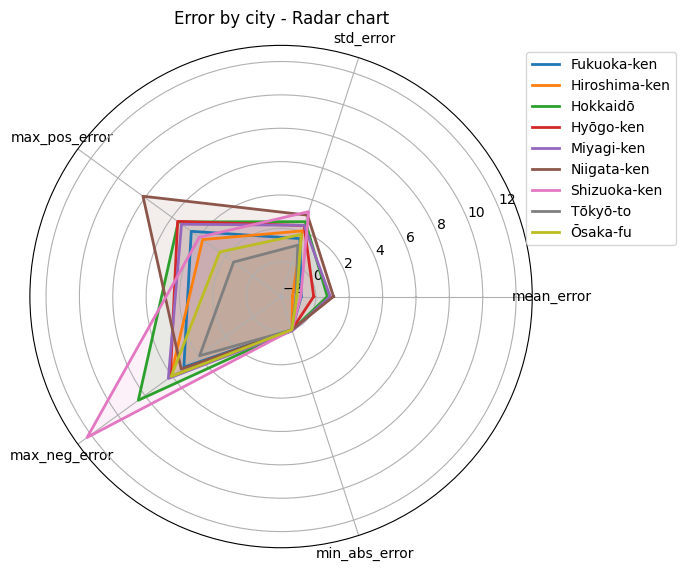

In [13]:
categories = [
    MEAN_ERROR,
    STD_ERROR,
    MAX_POS_ERROR,
    MAX_NEG_ERROR,
    MIN_ABS_ERROR
]
plot_error_radar(city_group_error_info, CITY_COL, categories, False)

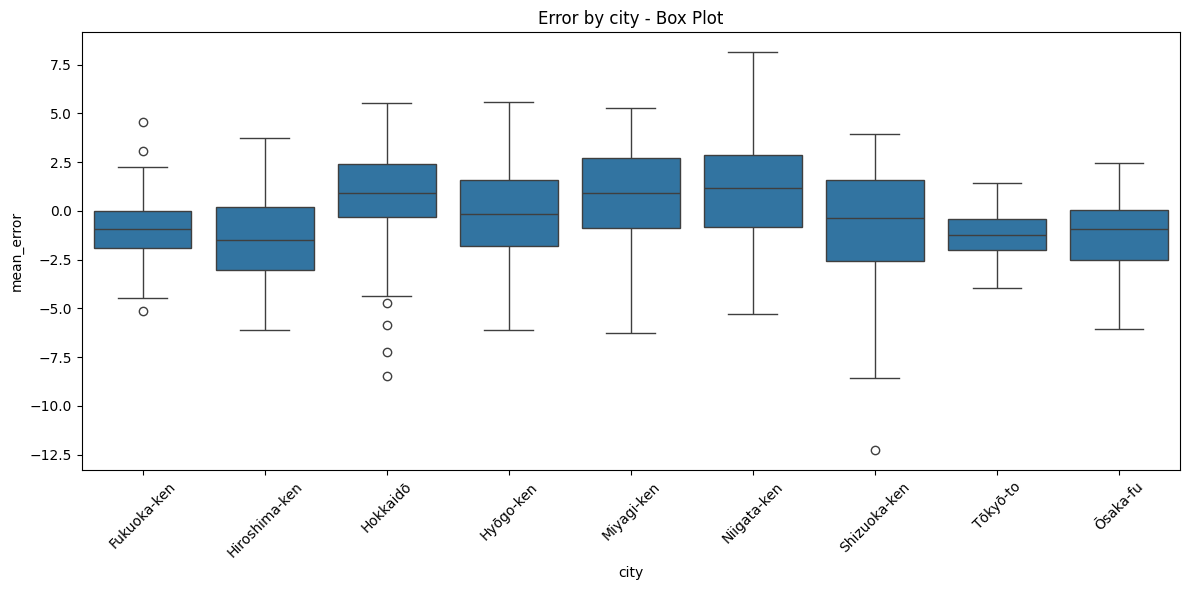

In [14]:
plot_errors_boxplot(X_test, y_test, y_test_pred, CITY_COL)

#### Genres

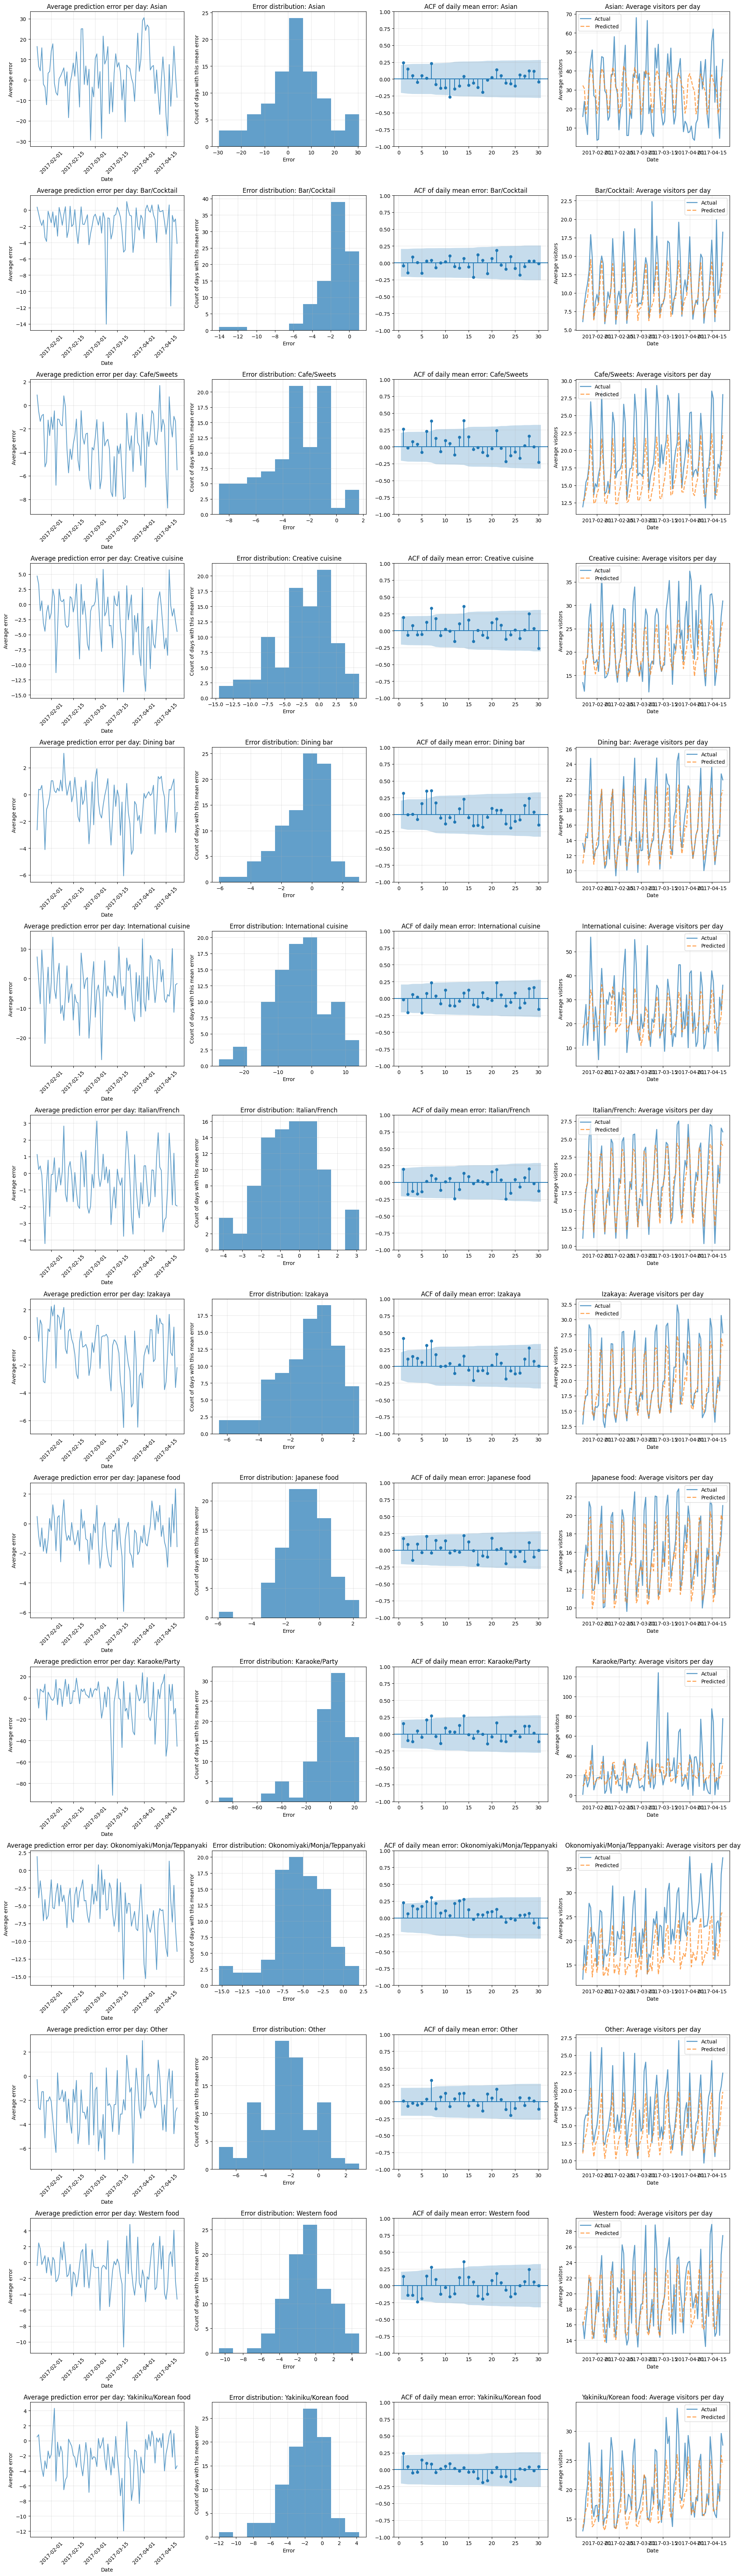

In [27]:
plot_daily_error_by_group(X_test, y_test, y_test_pred, AIR_GENRE_COL)

The largest residuals are observed for restaurants with the Asian and Karaoke/Party genres. However, firstly, the model doesn't consider the genre_te parameter. And if we recall the previous analysis, we see that there are fewer than five restaurants for each of these genres. Creating a different model for them is a questionable idea, but we can try removing the genre with some threshold and retraining the model.

In [15]:
genre_group_error_info = get_daily_error_stats_table(X_test, y_test, y_test_pred, AIR_GENRE_COL)
genre_group_error_info

,air_genre_name,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Asian,3.615,11.989,0.091,35.396,25.671,0.253,0.211,0.119,0.022,0.119,-0.023,0.175,-0.113,-0.139,-0.117,-0.229,-0.095,-0.111,-0.026
1,Bar/Cocktail,-0.640,2.164,0.007,2.965,13.160,-0.069,-0.090,0.123,0.041,-0.109,0.018,-0.056,-0.134,0.023,0.008,0.072,-0.078,-0.102,0.058
2,Cafe/Sweets,-2.222,2.097,0.044,2.895,7.370,0.283,0.111,0.227,0.175,-0.010,0.146,0.309,0.095,-0.000,0.270,0.212,-0.059,0.128,0.363
3,Creative cuisine,-1.714,3.740,0.003,5.947,12.101,0.106,-0.033,0.227,0.038,-0.024,0.018,0.256,0.149,-0.083,0.110,0.060,-0.182,0.009,0.229
4,Dining bar,0.074,1.321,0.006,3.722,3.696,0.268,0.118,0.144,0.003,0.217,0.288,0.214,-0.005,-0.050,-0.070,0.026,-0.102,-0.082,0.041
5,International cuisine,-2.390,7.684,0.021,14.589,26.388,-0.021,-0.144,0.151,0.121,-0.165,0.055,0.236,0.042,-0.072,0.172,-0.048,-0.057,-0.089,0.080
6,Italian/French,-0.011,1.429,0.008,2.892,3.547,0.240,-0.047,-0.135,-0.183,-0.164,-0.054,0.049,-0.025,-0.138,0.005,0.077,-0.279,-0.129,0.115
7,Izakaya,-0.457,1.581,0.033,3.239,6.605,0.426,0.277,0.284,0.250,0.221,0.308,0.253,0.035,0.018,0.027,0.080,-0.100,-0.115,-0.068
8,Japanese food,-0.340,1.180,0.021,3.342,2.505,0.183,0.191,-0.116,0.184,0.038,0.215,-0.127,0.103,-0.069,0.184,-0.049,0.111,0.042,0.181
9,Karaoke/Party,-0.514,17.904,0.263,34.971,77.414,0.176,-0.074,-0.112,0.093,0.016,0.067,0.094,-0.123,-0.084,0.173,0.100,0.112,0.162,0.280


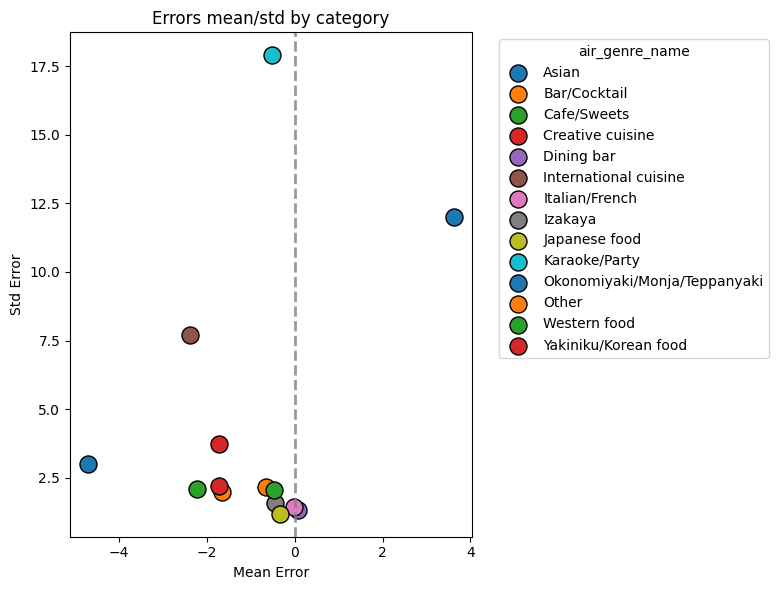

In [16]:
plot_error_mean_std(genre_group_error_info, AIR_GENRE_COL)

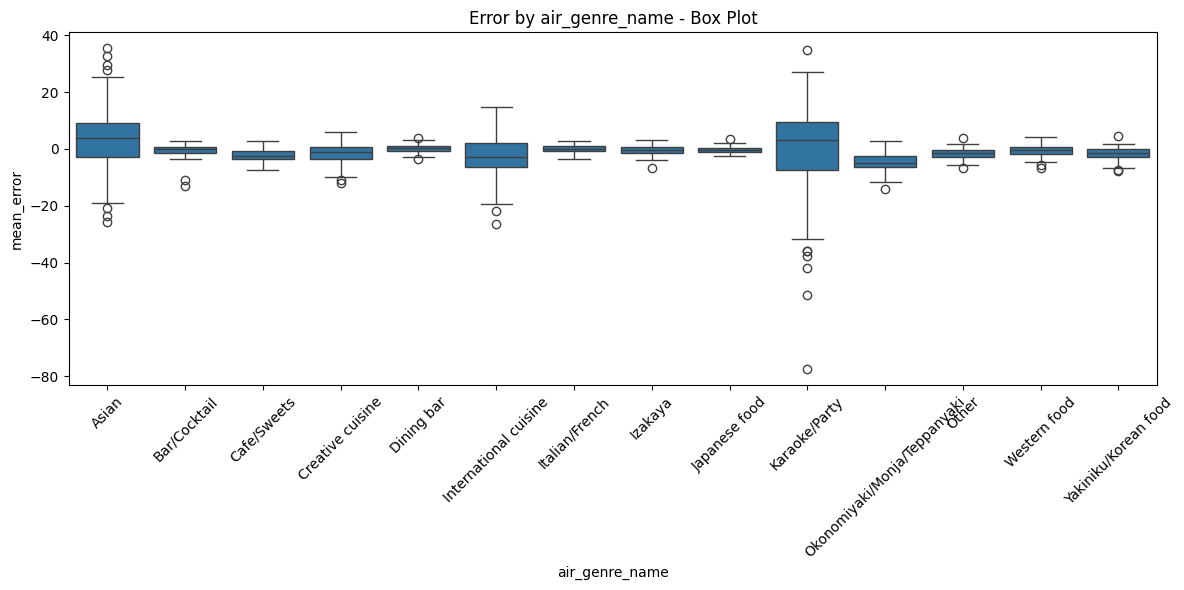

In [17]:
plot_errors_boxplot(X_test, y_test, y_test_pred, AIR_GENRE_COL)

## Testing on future data

In [3]:
model_shap = joblib.load(MODEL_PATH)

In [30]:
test_features = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv")
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [31]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [00:33<00:00,  1.18it/s]


In [32]:
labels_format = get_format(test_features, test_labels)
labels_format.to_csv(PROCESSED_DATA_DIR / "test_labels.csv", index=False)

## Saving model

In [35]:
with mlflow.start_run(run_name=MODEL_NAME):
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(
        best_cv_result,
        artifact_file="best_cv_result.json"
    )

    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("feature_selection_validation_size", FS_VALID_SIZE)
    mlflow.log_param("first_iteration_n_trials", FIRST_ITER_TRIALS)
    mlflow.log_param("second_iteration_n_trials", SECOND_ITER_TRIALS)
    mlflow.log_param("objective_function", OBJECTIVE_FUNCTION)
    mlflow.log_params(best_cv_result["params"])

    mlflow.log_metric("test_rmsle", test_rmsle)
    mlflow.log_metric("cv_mean_test_score", best_cv_result["mean_test_score"])
    mlflow.log_metric("cv_std_test_score", best_cv_result["std_test_score"])

    mlflow.sklearn.log_model(
        sk_model=model_shap,
        name="model"
    )

    mlflow.set_tags({
        "feature_ranking_method": "shap",
        "feature_selection_strategy": "top_k",
        "training_window_size": 39,
        "max_depth": "enabled"
    })

🏃 View run lgbm_optuna_recursive_huber at: http://localhost:5000/#/experiments/6/runs/f2949947905c4276800fd9bd4f0e72db
🧪 View experiment at: http://localhost:5000/#/experiments/6
